<a href="https://colab.research.google.com/github/Gbriel26/IA_TEMA_ML/blob/main/IA_TEMA_ML_4_(K_Nearest_Neighbors_KNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
# Añadimos los nombres de las columnas que se ven en el archivo .names
column_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
data = pd.read_csv('car.data', names=column_names)

data.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [3]:
# Información general sobre los datos
print("Resumen de los datos:")
data.info()

Resumen de los datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [5]:
# Convertir valores categóricos a numéricos
label_encoders = {}
for column in data.columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

print("Datos después de convertir a numéricos:")
data.head()

Datos después de convertir a numéricos:


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [6]:
# Separar las características (X) y la variable objetivo (y)
X = data.drop('class', axis=1)
y = data['class']

In [7]:
# Normalizar los datos
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [8]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# P Entrenar el modelo KNN
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Evaluar el modelo
# Realizar predicciones
y_pred = knn.predict(X_test)

In [9]:
# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:")
print(conf_matrix)


Matriz de confusión:
[[104   0  11   3]
 [ 11   7   0   1]
 [  4   0 354   0]
 [  6   1   2  15]]


In [10]:
# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       118
           1       0.88      0.37      0.52        19
           2       0.96      0.99      0.98       358
           3       0.79      0.62      0.70        24

    accuracy                           0.92       519
   macro avg       0.87      0.72      0.76       519
weighted avg       0.92      0.92      0.92       519



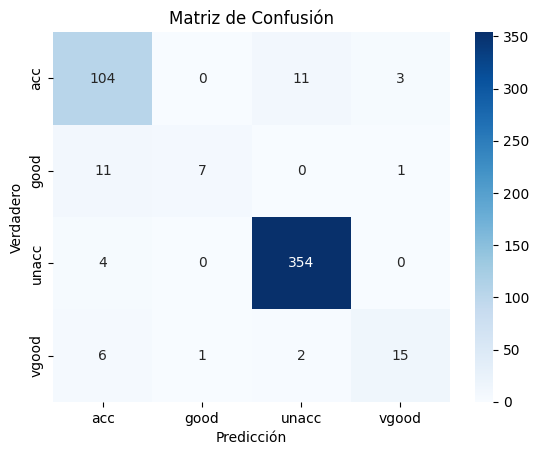

In [11]:
# Visualizar la matriz de confusión
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=label_encoders['class'].classes_,
            yticklabels=label_encoders['class'].classes_)
plt.ylabel('Verdadero')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')
plt.show()

In [12]:
# Exactitud
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy * 100:.2f}%")

Exactitud del modelo: 92.49%


In [13]:
# Ejemplos de nuevos datos
new_data = [
    ['high', 'low', '2', '4', 'small', 'med'],
    ['low', 'high', '4', 'more', 'big', 'high']
]

# Convertir los nuevos datos con los mismos LabelEncoders
new_data_transformed = []
for row in new_data:
    encoded_row = [label_encoders[column].transform([value])[0] for column, value in zip(data.columns[:-1], row)]
    new_data_transformed.append(encoded_row)

# Normalizar los nuevos datos
new_data_transformed = scaler.transform(new_data_transformed)

# Realizar predicciones
new_predictions = knn.predict(new_data_transformed)

# Mostrar predicciones
print("\nPredicciones para nuevos datos:")
for i, prediction in enumerate(new_predictions):
    print(f"Datos: {new_data[i]}, Predicción: {label_encoders['class'].inverse_transform([prediction])[0]}")


Predicciones para nuevos datos:
Datos: ['high', 'low', '2', '4', 'small', 'med'], Predicción: unacc
Datos: ['low', 'high', '4', 'more', 'big', 'high'], Predicción: vgood


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
